# Palace CPW Simulation — Wave Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure with **wave ports**.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Define GSG electrode

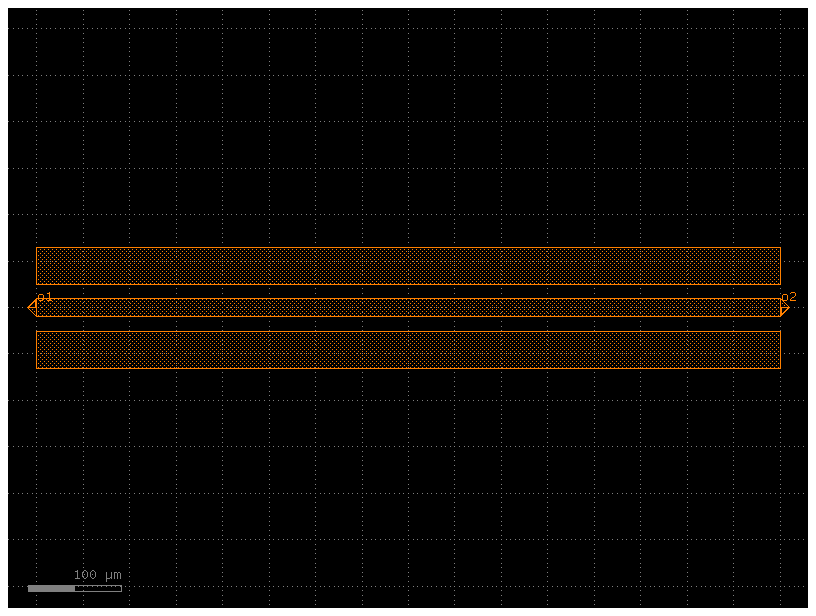

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure simulation

In [2]:
from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-cpw-waveport")
sim.set_geometry(c)

stack = get_stack()  # auto-detects active PDK
sim.set_stack(stack)
sim.set_airbox(margin_x=0.0, margin_y=50, z_above=100.0, z_below=100.0)

# Wave ports — max_size fills the full domain boundary
sim.add_wave_port("o1", layer="topmetal2", max_size=True, mode=1, excited=True)
sim.add_wave_port("o2", layer="topmetal2", max_size=True, mode=1, excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

print(sim.validate_config())

Validation: PASSED


### Generate mesh

In [3]:
sim.mesh(preset="default", refined_mesh_size=2.0, max_mesh_size=40.0, fmax=150e9)

Mesh Summary
Dimensions: 800.0 x 330.0 x 217.9 µm
Nodes:      43,842
Elements:   314,803
Tetrahedra: 231,263
Edge length: 1.08 - 80.27 µm
Quality:    0.634 (min: 0.000)
SICN:       0.686 (all valid)
----------------------------------------
Volumes (3):
  - si [1]
  - sin [2]
  - air [3]
Surfaces (9):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - P1 [6]
  - P2 [7]
  - si__None [8]
  - air__si [9]
  - si__sin [10]
  - air__sin [11]
  - air__None [12]
----------------------------------------
Mesh:   palace-sim-cpw-waveport/palace.msh

In [4]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:37967/index.html?ui=P_0x7fe248efe480_0&reconnect=auto" class="pyvi…

### Run simulation

In [5]:
results = sim.run()

  palace-1ce34fb3  completed  9m 24s


Extracting results.tar.gz...
Downloaded 8 files to sim-data-palace-1ce34fb3


### Plot S-parameters

In [6]:
results.plot_interactive()

Port mapping: Port 1: p1, Port 2: p2


In [7]:
results.plot_interactive(phase=True)

Port mapping: Port 1: p1, Port 2: p2
